In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
import optuna

In [22]:
df = pd.read_csv('gemini.csv')

In [32]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [33]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

predictions = model.predict(X_test)
y_pred = model.predict(X_test)         
y_proba = model.predict_proba(X_test)   

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 87.50%


Accuracy:0.875
Precision:0.917
Recall:  0.846
F1-score: 0.880

Confusion Matrix:
 [[10  1]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        11
         1.0       0.92      0.85      0.88        13

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.88        24

F1-результаты по фолдам: [0.8 0.8 1.  1.  1. ]
Средний F1: 0.92


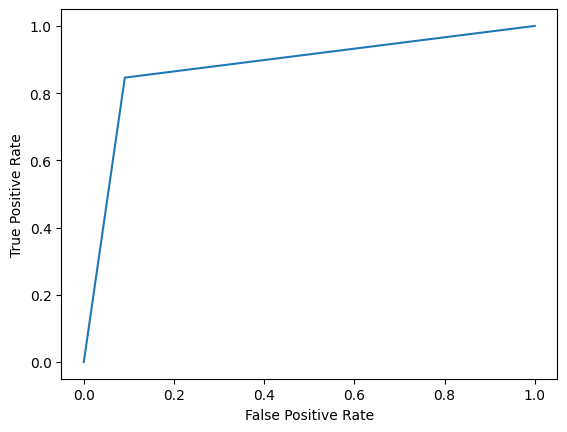

In [34]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

Accuracy:0.875
Precision:0.917
Recall:  0.846
F1-score: 0.880

Confusion Matrix:
 [[10  1]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        11
         1.0       0.92      0.85      0.88        13

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.88        24

F1-результаты по фолдам: [0.8 0.8 1.  1.  1. ]
Средний F1: 0.92


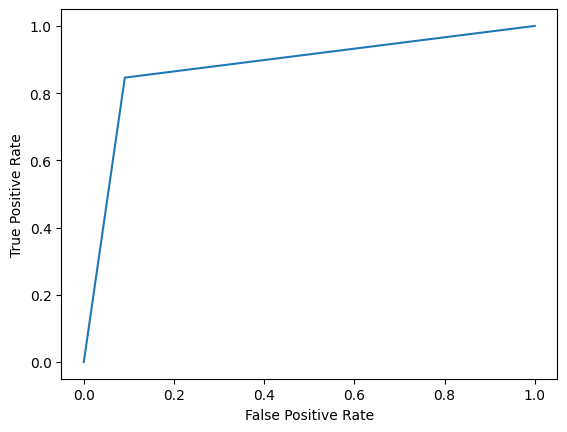

In [35]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [36]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba[:, 1]):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.875
Precision:0.917
Recall:  0.846
F1-score: 0.880
ROC-AUC:0.916

Confusion Matrix:
 [[10  1]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        11
         1.0       0.92      0.85      0.88        13

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.88        24



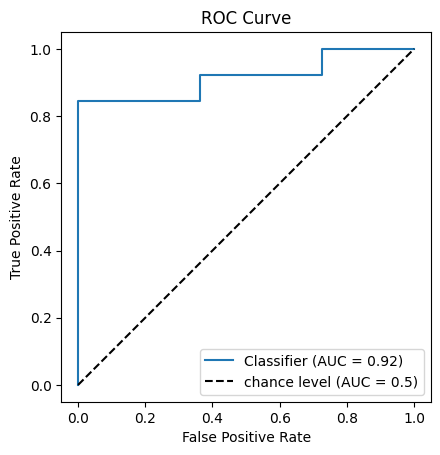

In [37]:
RocCurveDisplay.from_predictions(y_test, y_proba[:, 1])

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

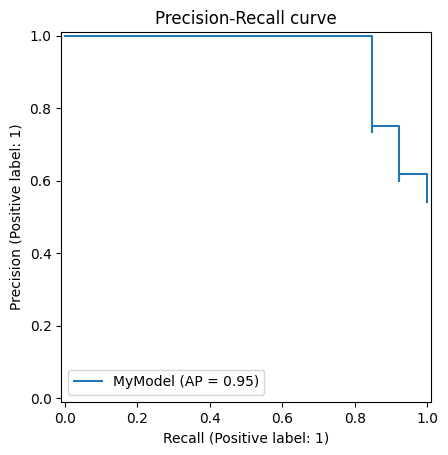

In [38]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba[:, 1], name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()